# Step 4: Standard Protocol (train on session T, test on session E)

Notebook 03 could only use the training session (`T`), because the evaluation-session (`E`) labels were missing. Models were therefore trained on 192 trials, and the numbers could not be compared with published results.

This notebook follows the **standard BCI IV-2a protocol**: **train on all 288 `T` trials, test once on all 288 `E` trials** (recorded on a different day). The comparison reference is Nzakuna et al. (2025), Table 2, which uses exactly this protocol with EEGNet.

| Phase | What | Uses E? |
|---|---|---|
| 1 | Official E labels downloaded and verified | labels only |
| 2 | 4 preprocessing options compared by cross-validation **inside T**; best option and epoch count chosen | **no** |
| 3 | Chosen option: train on 288 T trials, test on E, **5 random seeds** | test only |
| 4 | All 4 options tested on E (extra information, not used for any choice) | test only |
| 5 | Cross-subject LOSO on both sessions (train 8 subjects T+E, test the unseen subject), 3 seeds | test only |

**Nothing is tuned on the E session.** Every choice (preprocessing, number of epochs) is made from T data only, so the E results are an honest test.

All training runs were executed by `experiments/run_experiments.py`. Each run's metrics, predictions, logits and training history are in `results/runs/`, and its model weights (checkpoint) are in `checkpoints/`. This notebook only loads and analyses them.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.stats import wilcoxon
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent / "src"))
from data import CLASS_NAMES, SUBJECTS, labelled_events, load_raw
from models import EEGNet
from plots import per_class_recall, plot_confusion_grid, plot_curves_grid, plot_recall_heatmap
from preprocess import CONFIGS, load_config_data
from results_io import CKPT_DIR, RUNS_DIR, load_runs, pooled_predictions, selection
from train import ChannelScaler, predict_logits

RESULTS = Path.cwd().parent / "results"
FIG_DIR = RESULTS / "figures"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

def per_subject_table(runs, metric_path=lambda r: r["metrics"]):
    """Mean ± std over seeds for each subject, plus the mean over subjects."""
    df = pd.DataFrame([{"subject": r["subject"], "seed": r["seed"], **metric_path(r)} for r in runs])
    agg = df.groupby("subject")[["accuracy", "kappa", "macro_f1"]].agg(["mean", "std"])
    return df, agg

## Phase 1: Evaluation-session labels
The official labels come from the BCI Competition IV website (`true_labels.zip`, saved in `Dataset/true_labels/`). The zip also contains the `T` labels, which gives a built-in check: they must agree trial by trial with the class cues stored in the `T` recordings.

In [2]:
rows = []
for s in SUBJECTS:
    for sess in "TE":
        raw = load_raw(s, sess, preload=False)
        events, _ = labelled_events(raw, s, sess)      # asserts 288 cues, 72/class, and T agreement
        rows.append({"recording": f"{s}{sess}", "trials": len(events),
                     **dict(zip(CLASS_NAMES, np.bincount(events[:, 2], minlength=4))),
                     "check": "labels = cue codes in file" if sess == "T" else "288 cues (code 783) labelled"})
label_table = pd.DataFrame(rows)
print("All 18 recordings: 288 labelled trials, 72 per class. T label files agree with the recorded cues.")
label_table.head(4)

All 18 recordings: 288 labelled trials, 72 per class. T label files agree with the recorded cues.


,recording,trials,left_hand,right_hand,feet,tongue,check
0,A01T,288,72,72,72,72,labels = cue codes in file
1,A01E,288,72,72,72,72,288 cues (code 783) labelled
2,A02T,288,72,72,72,72,labels = cue codes in file
3,A02E,288,72,72,72,72,288 cues (code 783) labelled


## Preprocessing options
All options drop the 3 EOG channels, epoch around the cue, and use the official labels for both sessions. Filters and exponential moving standardization run on the continuous signal before epoching.

In [3]:
opt = pd.DataFrame([{"option": k, "description": v["label"],
                     "band-pass": f"{v['l_freq']:g}–{v['h_freq']:g} Hz" if v["l_freq"] else "none (0.5–100 Hz as recorded)",
                     "window after cue": f"{v['tmin']:g} to {v['tmax']:g} s",
                     "samples": int(round((v['tmax'] - v['tmin']) * 250)),
                     "exp. moving standardization": "yes" if v["ems"] else "no"} for k, v in CONFIGS.items()])
opt

,option,description,band-pass,window after cue,samples,exp. moving standardization
0,A,"8-30 Hz, 0-4 s after cue (Steps 2-3)",8–30 Hz,0 to 4 s,1000,no
1,B,"8-30 Hz, 0.5-4.5 s after cue",8–30 Hz,0.5 to 4.5 s,1000,no
2,C,"4-38 Hz, 0.5-4.5 s after cue",4–38 Hz,0.5 to 4.5 s,1000,no
3,D,"no extra filter, -0.5-4 s, exp. moving standar...",none (0.5–100 Hz as recorded),-0.5 to 4 s,1125,yes


## Phase 2: Choosing the preprocessing and the number of epochs (T session only)

For each option, subject and fold (6 folds: train on 5 runs = 240 trials, evaluate on the held-out run = 48 trials), EEGNet is trained for **500 epochs**, and the held-out-run accuracy is recorded **after every epoch**. Averaging these curves over 9 subjects × 6 folds = 54 runs gives, for each option, the expected accuracy as a function of training length.

**Decision rule** (fixed before looking at any result): smooth the mean curve (25-epoch moving average) and pick the option and epoch count with the highest value.

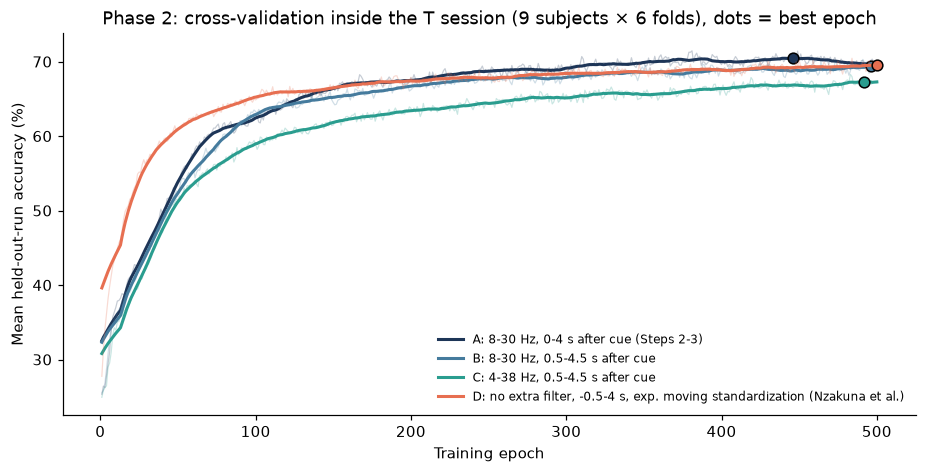

Chosen option: A (8-30 Hz, 0-4 s after cue (Steps 2-3)), trained for 446 epochs


,label,best_epochs,cv_acc_at_best,cv_acc_final_epoch
A,"8-30 Hz, 0-4 s after cue (Steps 2-3)",446,70.47,69.87
B,"8-30 Hz, 0.5-4.5 s after cue",496,69.39,69.64
C,"4-38 Hz, 0.5-4.5 s after cue",492,67.33,67.17
D,"no extra filter, -0.5-4 s, exp. moving standar...",500,69.51,69.75


In [4]:
sel = selection()
fig, ax = plt.subplots(figsize=(10, 4.5))
colors = {"A": "#1d3557", "B": "#457b9d", "C": "#2a9d8f", "D": "#e76f51"}
cv_curves = {}
for c in CONFIGS:
    runs = load_runs("select", c)
    assert len(runs) == 54, f"{c}: {len(runs)} runs"
    mean_curve = np.mean([r["history"]["mon_acc"] for r in runs], axis=0) * 100
    cv_curves[c] = runs
    k = sel["smoothing_window"] // 2
    smooth = np.array([mean_curve[max(0, i - k): i + k + 1].mean() for i in range(len(mean_curve))])
    ep = np.arange(1, len(mean_curve) + 1)
    ax.plot(ep, mean_curve, color=colors[c], alpha=0.25, lw=0.8)
    ax.plot(ep, smooth, color=colors[c], lw=2, label=f"{c}: {CONFIGS[c]['label']}")
    b = sel["configs"][c]["best_epochs"]
    ax.plot(b, smooth[b - 1], "o", color=colors[c], ms=7, mec="black")
ax.set_xlabel("Training epoch"); ax.set_ylabel("Mean held-out-run accuracy (%)")
ax.set_title("Phase 2: cross-validation inside the T session (9 subjects × 6 folds), dots = best epoch")
ax.legend(frameon=False, fontsize=8, loc="lower right")
fig.savefig(FIG_DIR / "04_phase2_selection_curves.png", bbox_inches="tight")
plt.show()

sel_table = pd.DataFrame(sel["configs"]).T[["label", "best_epochs", "cv_acc_at_best", "cv_acc_final_epoch"]]
sel_table["cv_acc_at_best"] = (sel_table["cv_acc_at_best"].astype(float) * 100).round(2)
sel_table["cv_acc_final_epoch"] = (sel_table["cv_acc_final_epoch"].astype(float) * 100).round(2)
print(f"Chosen option: {sel['chosen_config']} ({CONFIGS[sel['chosen_config']]['label']}), "
      f"trained for {sel['configs'][sel['chosen_config']]['best_epochs']} epochs")
sel_table

In [5]:
# Per-subject CV accuracy at each option's chosen epoch (T session only)
rows = []
for c, runs in cv_curves.items():
    b = sel["configs"][c]["best_epochs"]
    for s in SUBJECTS:
        accs = [r["history"]["mon_acc"][b - 1] for r in runs if r["subject"] == s]
        rows.append({"subject": s, "option": c, "cv_acc": 100 * np.mean(accs)})
cv_subject = pd.DataFrame(rows).pivot(index="subject", columns="option", values="cv_acc").round(1)
cv_subject.loc["mean"] = cv_subject.mean().round(1)
cv_subject

option,A,B,C,D
subject,,,,
A01,79.5,77.8,73.6,67.4
A02,54.5,55.2,51.7,52.8
A03,90.6,90.3,91.0,78.8
A04,51.7,47.9,46.2,59.7
A05,64.9,63.5,48.6,71.9
A06,49.0,43.8,46.2,59.7
A07,74.7,71.5,83.7,77.4
A08,86.8,85.8,87.5,77.1
A09,87.5,84.7,80.9,83.0


## Phase 3: Main result, chosen option, train on T (288 trials), test on E (288 trials), 5 seeds

In [6]:
CH = sel["chosen_config"]
t2e = load_runs("t2e", CH)
assert len(t2e) == 45, len(t2e)
t2e_df, t2e_agg = per_subject_table(t2e)

main = pd.DataFrame({
    "accuracy (%)": (t2e_agg[("accuracy", "mean")] * 100).round(2).astype(str) + " ± " + (t2e_agg[("accuracy", "std")] * 100).round(2).astype(str),
    "kappa": t2e_agg[("kappa", "mean")].round(3).astype(str) + " ± " + t2e_agg[("kappa", "std")].round(3).astype(str),
    "macro-F1": t2e_agg[("macro_f1", "mean")].round(3).astype(str) + " ± " + t2e_agg[("macro_f1", "std")].round(3).astype(str),
})
seed_means = t2e_df.groupby("seed")[["accuracy", "kappa", "macro_f1"]].mean()      # 9-subject mean per seed
subj_means = t2e_df.groupby("subject")[["accuracy", "kappa", "macro_f1"]].mean()    # seed-averaged per subject
print(f"Option {CH}: {CONFIGS[CH]['label']}, {t2e[0]['settings']['epochs']} epochs, 5 seeds")
print(f"Mean over subjects: accuracy {100 * subj_means.accuracy.mean():.2f}% "
      f"(std across subjects {100 * subj_means.accuracy.std():.2f}), kappa {subj_means.kappa.mean():.3f}, "
      f"macro-F1 {subj_means.macro_f1.mean():.3f}")
print(f"Seed-to-seed variation of the 9-subject mean accuracy: "
      f"{100 * seed_means.accuracy.min():.2f}–{100 * seed_means.accuracy.max():.2f}% (std {100 * seed_means.accuracy.std():.2f})")
t2e_df.to_csv(RESULTS / "eegnet_t2e_main.csv", index=False)
main

Option A: 8-30 Hz, 0-4 s after cue (Steps 2-3), 446 epochs, 5 seeds
Mean over subjects: accuracy 68.20% (std across subjects 15.85), kappa 0.576, macro-F1 0.673
Seed-to-seed variation of the 9-subject mean accuracy: 67.28–69.41% (std 0.91)


,accuracy (%),kappa,macro-F1
subject,,,
A01,81.46 ± 3.23,0.753 ± 0.043,0.813 ± 0.032
A02,46.94 ± 3.78,0.293 ± 0.05,0.444 ± 0.044
A03,89.72 ± 2.74,0.863 ± 0.037,0.894 ± 0.031
A04,59.51 ± 3.6,0.46 ± 0.048,0.59 ± 0.039
A05,54.37 ± 3.65,0.392 ± 0.049,0.521 ± 0.038
A06,49.93 ± 4.07,0.332 ± 0.054,0.484 ± 0.055
A07,70.76 ± 4.38,0.61 ± 0.058,0.703 ± 0.046
A08,78.82 ± 0.81,0.718 ± 0.011,0.783 ± 0.01
A09,82.29 ± 2.61,0.764 ± 0.035,0.823 ± 0.026


### Comparison with published results (Nzakuna et al., 2025, Table 2, EEGNet, same T → E protocol)
- **MCD** and **MCSD** are the fairest comparison: **one network** each, although their prediction averages 200 stochastic forward passes (Monte Carlo dropout). Ours is a single deterministic pass.
- **EMCD / E-Dropout** are ensembles of 15 EEGNets. **LEMC-FTDB** is their proposed method (15 networks × 200 stochastic passes + per-model temperature + learned aggregation).
- Differences in setup (their Section IV): no extra band-pass filter, a −0.5–4 s window, exponential moving standardization, 500 epochs, batch 64, a temporal kernel of 32 samples, and FT-DropBlock layers in place of dropout. Our option D reproduces their preprocessing but keeps the original EEGNet.

,mean accuracy (%),std across subjects,mean kappa
"Ours (single EEGNet, mean of 5 seeds)",68.20,15.85,0.576
MCD (single EEGNet),71.14,9.91,0.617
MCSD (single EEGNet),70.60,9.70,0.609
EMCD (15-model ensemble),75.35,11.69,0.671
LEMC-FTDB (proposed),80.40,10.32,0.737


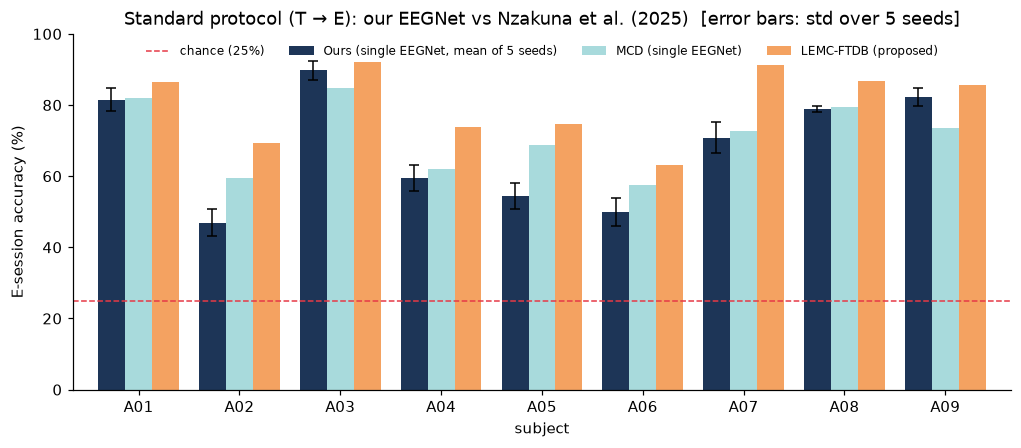

Ours - MCD per subject: mean -2.94 pp (range -14.38 to +8.68); Wilcoxon signed-rank p = 0.250 (n = 9)


In [7]:
ref = pd.read_csv(RESULTS / "reference_nzakuna2025_table2.csv").set_index("subject")
comp = pd.DataFrame({"Ours (single EEGNet, mean of 5 seeds)": subj_means.accuracy * 100,
                     "MCD (single EEGNet)": ref["MCD_acc"], "MCSD (single EEGNet)": ref["MCSD_acc"],
                     "EMCD (15-model ensemble)": ref["EMCD_acc"], "LEMC-FTDB (proposed)": ref["LEMC-FTDB_acc"]})
comp_k = pd.DataFrame({"Ours": subj_means.kappa, "MCD": ref["MCD_kappa"], "MCSD": ref["MCSD_kappa"],
                       "EMCD": ref["EMCD_kappa"], "LEMC-FTDB": ref["LEMC-FTDB_kappa"]})
summary = pd.DataFrame({"mean accuracy (%)": comp.mean().round(2), "std across subjects": comp.std().round(2),
                        "mean kappa": comp_k.mean().round(3).values})
display(summary)

ax = comp[["Ours (single EEGNet, mean of 5 seeds)", "MCD (single EEGNet)", "LEMC-FTDB (proposed)"]].plot.bar(
    figsize=(11, 4.2), color=["#1d3557", "#a8dadc", "#f4a261"], rot=0, width=0.8)
err = t2e_agg[("accuracy", "std")] * 100
ax.errorbar(np.arange(9) - 0.27, comp.iloc[:, 0].values, yerr=err.values, fmt="none", ecolor="black", capsize=3, lw=1)
ax.axhline(25, color="#e63946", ls="--", lw=1, label="chance (25%)")
ax.set_ylim(0, 100); ax.set_ylabel("E-session accuracy (%)")
ax.set_title("Standard protocol (T → E): our EEGNet vs Nzakuna et al. (2025)  [error bars: std over 5 seeds]")
ax.legend(frameon=False, fontsize=8, ncol=4, loc="upper center")
ax.figure.savefig(FIG_DIR / "04_t2e_vs_published.png", bbox_inches="tight")
plt.show()

stat, p = wilcoxon(comp.iloc[:, 0], comp["MCD (single EEGNet)"])
diff = comp.iloc[:, 0] - comp["MCD (single EEGNet)"]
print(f"Ours - MCD per subject: mean {diff.mean():+.2f} pp (range {diff.min():+.2f} to {diff.max():+.2f}); "
      f"Wilcoxon signed-rank p = {p:.3f} (n = 9)")

### Per-subject details (Phase 3)

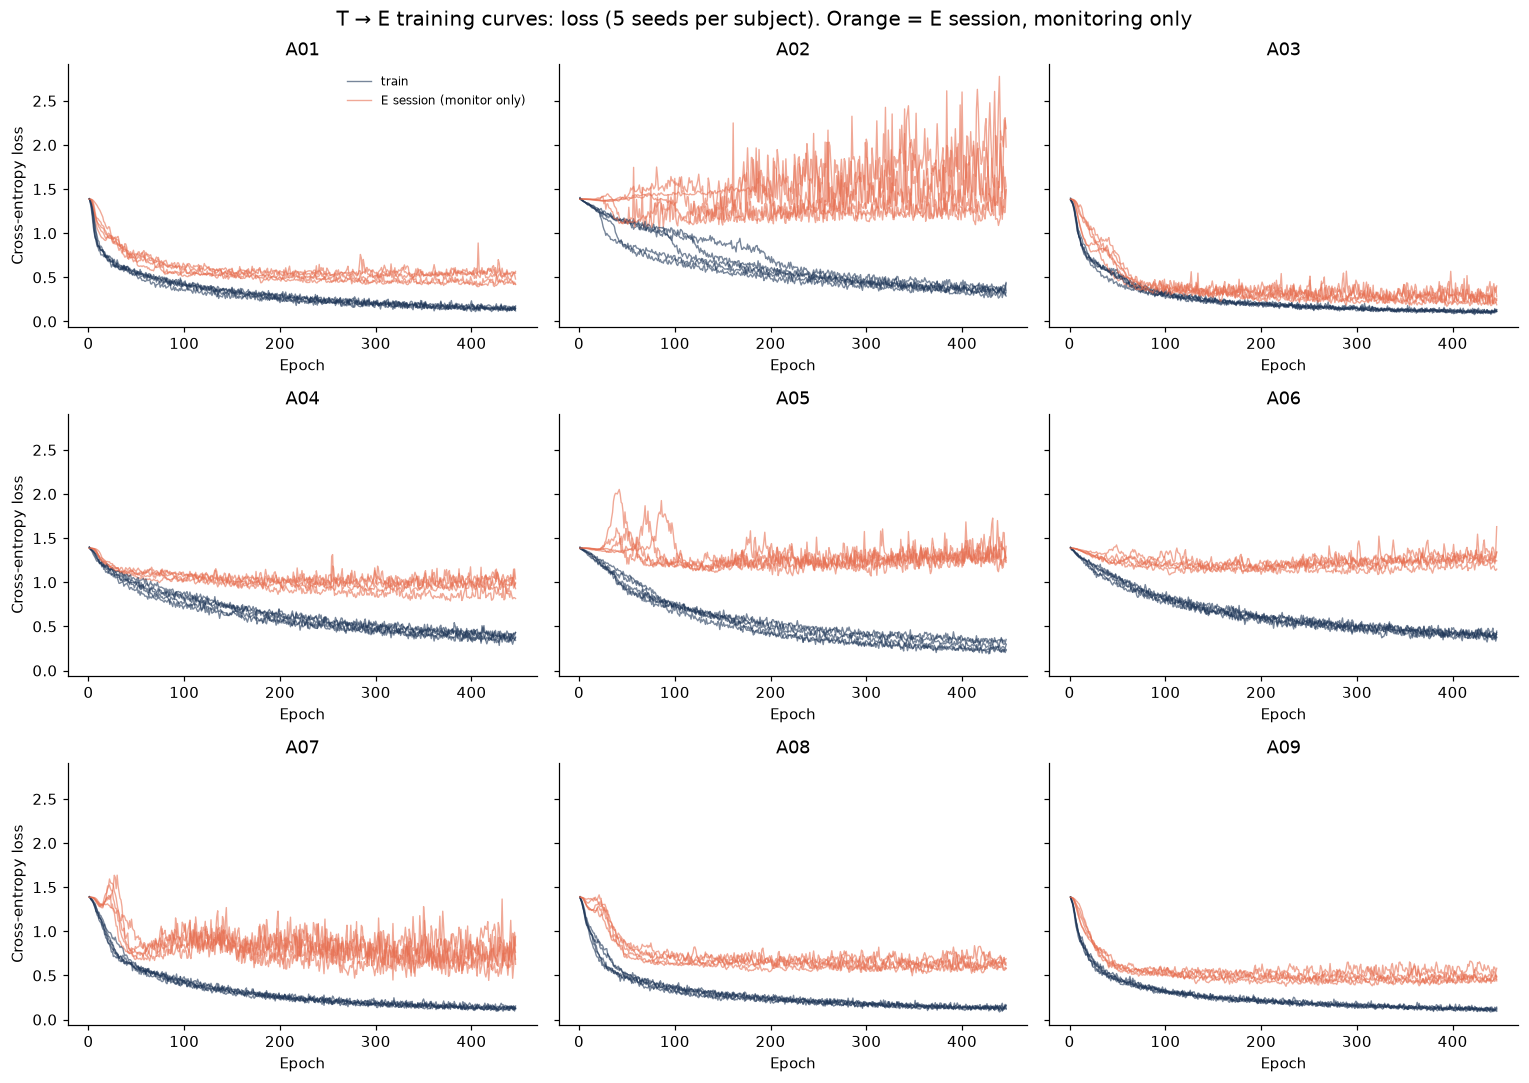

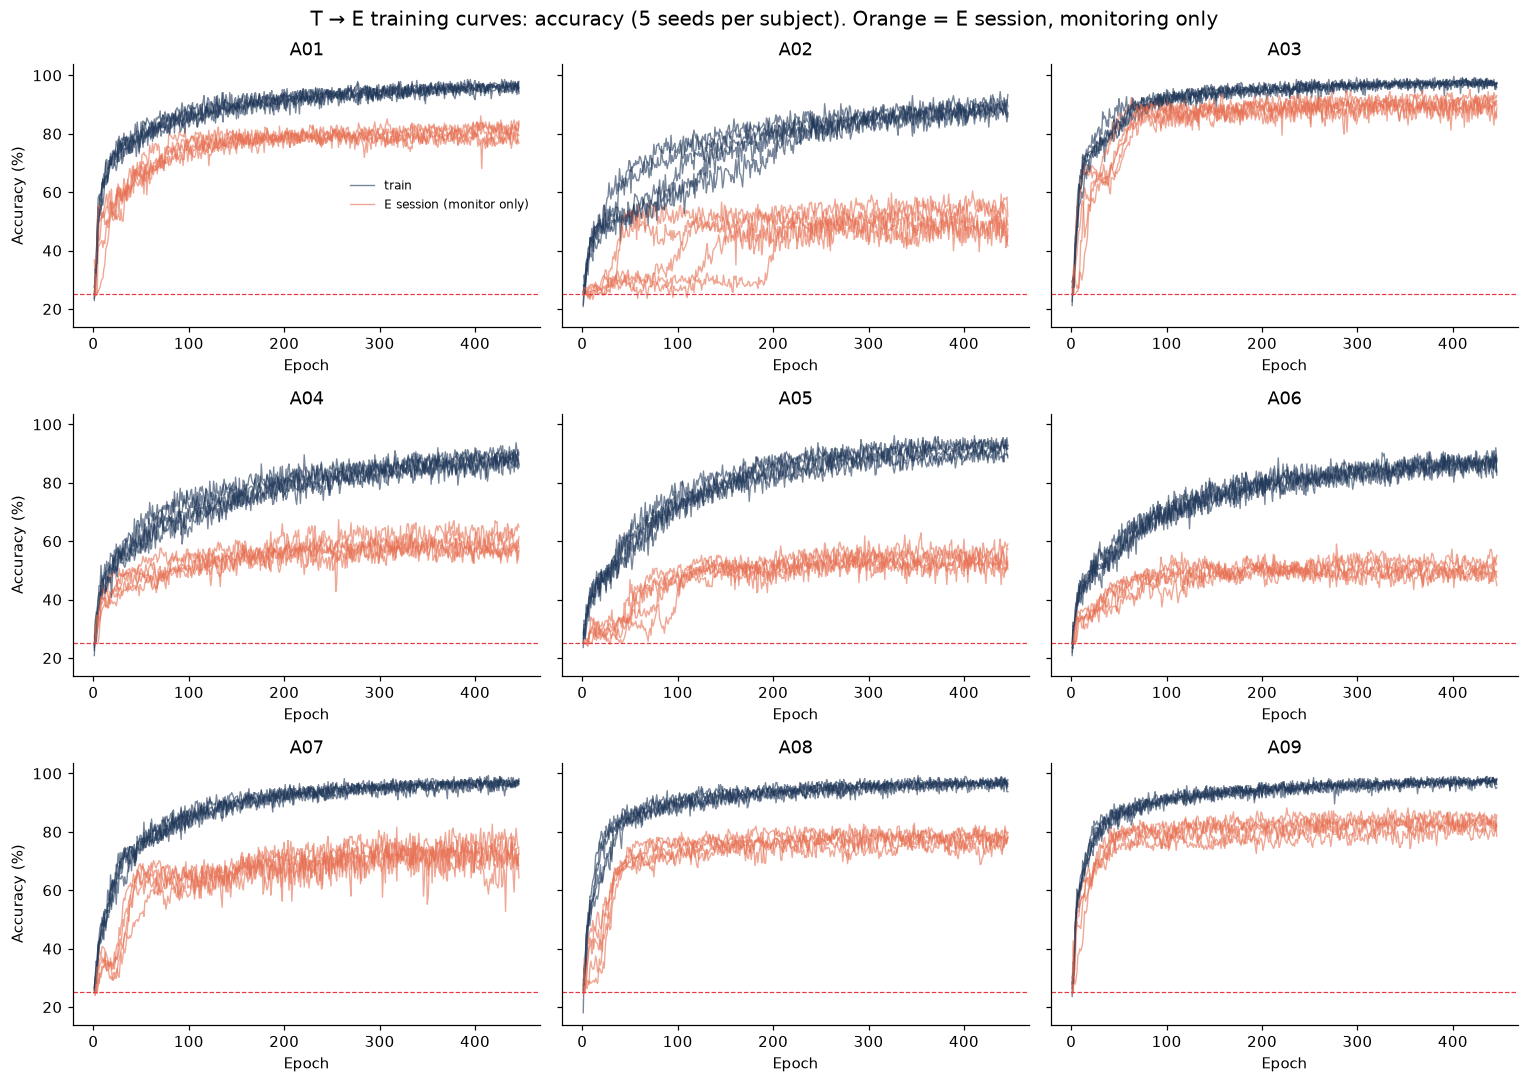

In [8]:
hist = {s: [r["history"] for r in t2e if r["subject"] == s] for s in SUBJECTS}
plot_curves_grid(hist, "loss", f"T → E training curves: loss (5 seeds per subject). Orange = E session, monitoring only",
                 FIG_DIR / "04_t2e_curves_loss.png", second="mon", second_label="E session (monitor only)", mark_best=False)
plt.show()
plot_curves_grid(hist, "acc", f"T → E training curves: accuracy (5 seeds per subject). Orange = E session, monitoring only",
                 FIG_DIR / "04_t2e_curves_accuracy.png", second="mon", second_label="E session (monitor only)", mark_best=False)
plt.show()

The orange E curves were **recorded only for these plots**. They were never used to stop training or to choose weights: every model trains for the fixed number of epochs chosen in Phase 2 from T data.

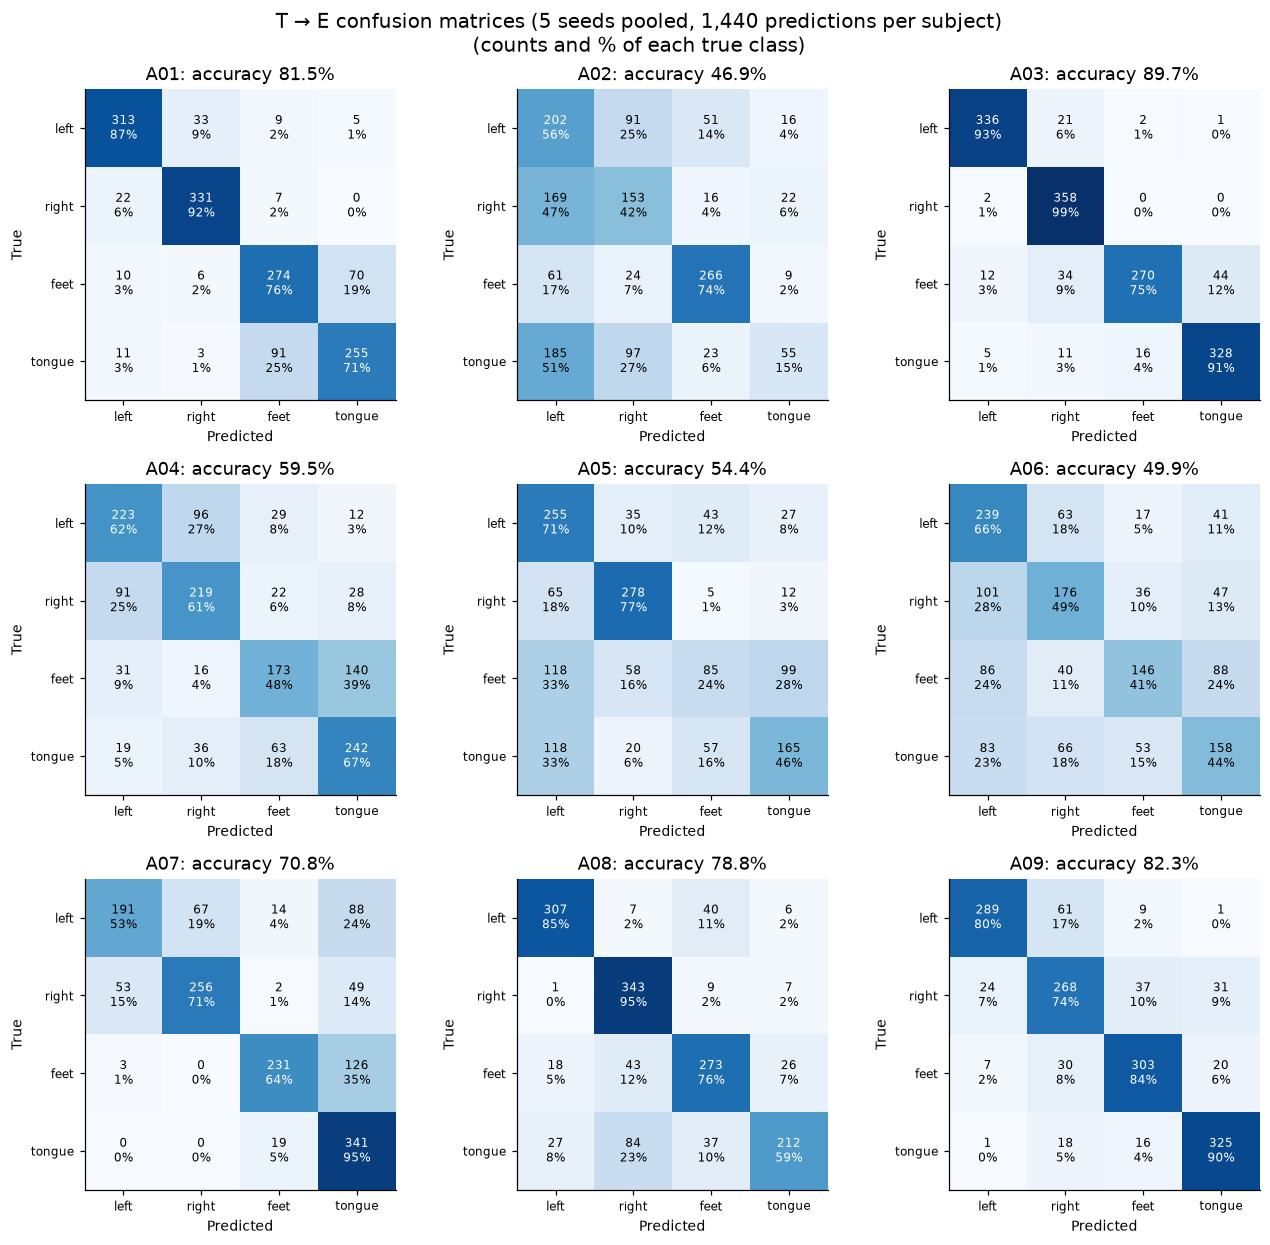

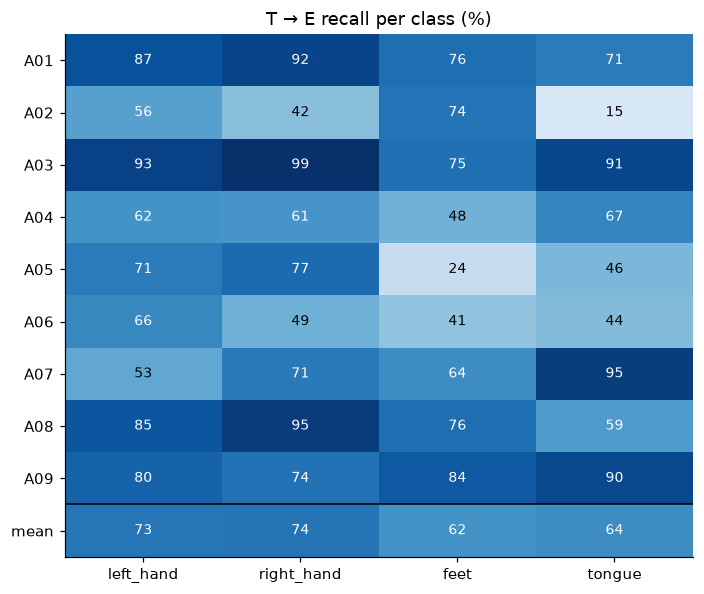

,left_hand,right_hand,feet,tongue
A01,86.9,91.9,76.1,70.8
A02,56.1,42.5,73.9,15.3
A03,93.3,99.4,75.0,91.1
A04,61.9,60.8,48.1,67.2
A05,70.8,77.2,23.6,45.8
A06,66.4,48.9,40.6,43.9
A07,53.1,71.1,64.2,94.7
A08,85.3,95.3,75.8,58.9
A09,80.3,74.4,84.2,90.3
mean,72.7,73.5,62.4,64.2


In [9]:
pp = pooled_predictions(t2e)
plot_confusion_grid({s: v[0] for s, v in pp.items()}, {s: v[1] for s, v in pp.items()}, CLASS_NAMES,
                    "T → E confusion matrices (5 seeds pooled, 1,440 predictions per subject)", "Blues",
                    FIG_DIR / "04_t2e_confusion_all_subjects.png")
plt.show()
t2e_recall = per_class_recall({s: v[0] for s, v in pp.items()}, {s: v[1] for s, v in pp.items()}, CLASS_NAMES)
plot_recall_heatmap(t2e_recall, "T → E recall per class (%)", "Blues", FIG_DIR / "04_t2e_recall_per_class.png")
plt.show()
t2e_recall

### Improvement over notebook 03
Notebook 03 used only 192 training trials (leave-one-run-out inside T), with option A.

In [10]:
nb03 = pd.read_csv(RESULTS / "eegnet_within_subject.csv").query("model == 'Ours'").set_index("subject")["accuracy"] * 100
imp = pd.DataFrame({"Notebook 03 (T-only CV, 192 trials)": nb03, "Notebook 04 (T → E, 288 trials)": subj_means.accuracy * 100})
imp.loc["mean"] = imp.mean()
imp.round(2)

,"Notebook 03 (T-only CV, 192 trials)","Notebook 04 (T → E, 288 trials)"
subject,,
A01,73.61,81.46
A02,38.54,46.94
A03,88.54,89.72
A04,37.50,59.51
A05,38.54,54.37
A06,37.15,49.93
A07,68.06,70.76
A08,81.25,78.82
A09,84.38,82.29


## Phase 4: All four options tested on E (extra information)
Each option is trained on T for its own Phase 2 epoch count and tested on E, 5 seeds each. This shows how much preprocessing matters on the real test session. **It was not used to choose anything.** The choice was fixed in Phase 2 using T only.

In [11]:
rows = []
for c in CONFIGS:
    runs = load_runs("t2e", c)
    assert len(runs) == 45, f"{c}: {len(runs)}"
    df, _ = per_subject_table(runs)
    for s, v in df.groupby("subject").accuracy.mean().items():
        rows.append({"subject": s, "option": c, "acc": 100 * v})
opt_e = pd.DataFrame(rows).pivot(index="subject", columns="option", values="acc")
opt_e.loc["mean"] = opt_e.mean()
opt_e = opt_e.round(2)
cv_rank = cv_subject.loc["mean"].sort_values(ascending=False).index.tolist()
e_rank = opt_e.loc["mean"].sort_values(ascending=False).index.tolist()
print("Ranking by T-session CV (used for the choice):", " > ".join(cv_rank))
print("Ranking on the E session (not used):          ", " > ".join(e_rank))
opt_e

Ranking by T-session CV (used for the choice): A > D > B > C
Ranking on the E session (not used):           A > B > D > C


option,A,B,C,D
subject,,,,
A01,81.46,82.08,80.69,73.40
A02,46.94,49.24,50.97,52.99
A03,89.72,88.68,89.38,84.03
A04,59.51,55.83,47.15,57.85
A05,54.37,55.62,42.64,66.88
A06,49.93,48.26,44.79,55.14
A07,70.76,74.17,78.06,69.38
A08,78.82,76.94,78.12,69.72
A09,82.29,81.04,80.00,70.69


## Phase 5: Cross-subject (LOSO) on both sessions
For each held-out subject: train on the other **8 subjects' T and E sessions (4,608 trials)**, with 20% of those trials held out for early stopping, then test on the **unseen subject's E session** (and, for reference, its T session). No alignment yet, so this is the **no-EA baseline** for the next step of the project. 3 seeds.

In [12]:
loso = load_runs("loso", CH)
assert len(loso) == 27, len(loso)
loso_df, loso_agg = per_subject_table(loso, metric_path=lambda r: r["target"]["E"]["metrics"])
loso_T = pd.DataFrame([{"subject": r["subject"], **r["target"]["T"]["metrics"]} for r in loso]).groupby("subject").mean()
loso_means = loso_df.groupby("subject")[["accuracy", "kappa", "macro_f1"]].mean()
loso_df.to_csv(RESULTS / "eegnet_loso_no_ea_standard.csv", index=False)

tab = pd.DataFrame({"within-subject T→E (%)": subj_means.accuracy * 100,
                    "LOSO, unseen subject E (%)": loso_means.accuracy * 100,
                    "LOSO std over 3 seeds": loso_agg[("accuracy", "std")] * 100,
                    "LOSO kappa": loso_means.kappa,
                    "LOSO, unseen subject T (%)": loso_T.accuracy * 100})
tab.loc["mean"] = tab.mean()
print(f"LOSO (no EA) mean accuracy on unseen subjects' E session: {100 * loso_means.accuracy.mean():.2f}% "
      f"(kappa {loso_means.kappa.mean():.3f}) vs within-subject {100 * subj_means.accuracy.mean():.2f}%")
tab.round(2)

LOSO (no EA) mean accuracy on unseen subjects' E session: 44.66% (kappa 0.262) vs within-subject 68.20%


,within-subject T→E (%),"LOSO, unseen subject E (%)",LOSO std over 3 seeds,LOSO kappa,"LOSO, unseen subject T (%)"
subject,,,,,
A01,81.46,62.62,4.40,0.50,61.46
A02,46.94,29.86,2.71,0.06,28.47
A03,89.72,64.35,6.74,0.52,57.99
A04,59.51,36.11,1.04,0.15,36.11
A05,54.37,25.93,1.31,0.01,26.04
A06,49.93,28.59,2.61,0.05,30.09
A07,70.76,31.71,2.03,0.09,36.46
A08,78.82,62.62,4.42,0.50,65.62
A09,82.29,60.19,3.82,0.47,53.24


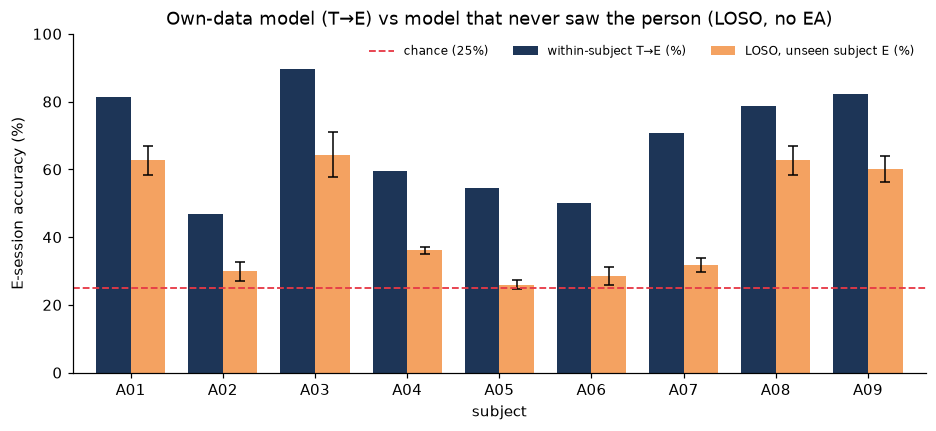

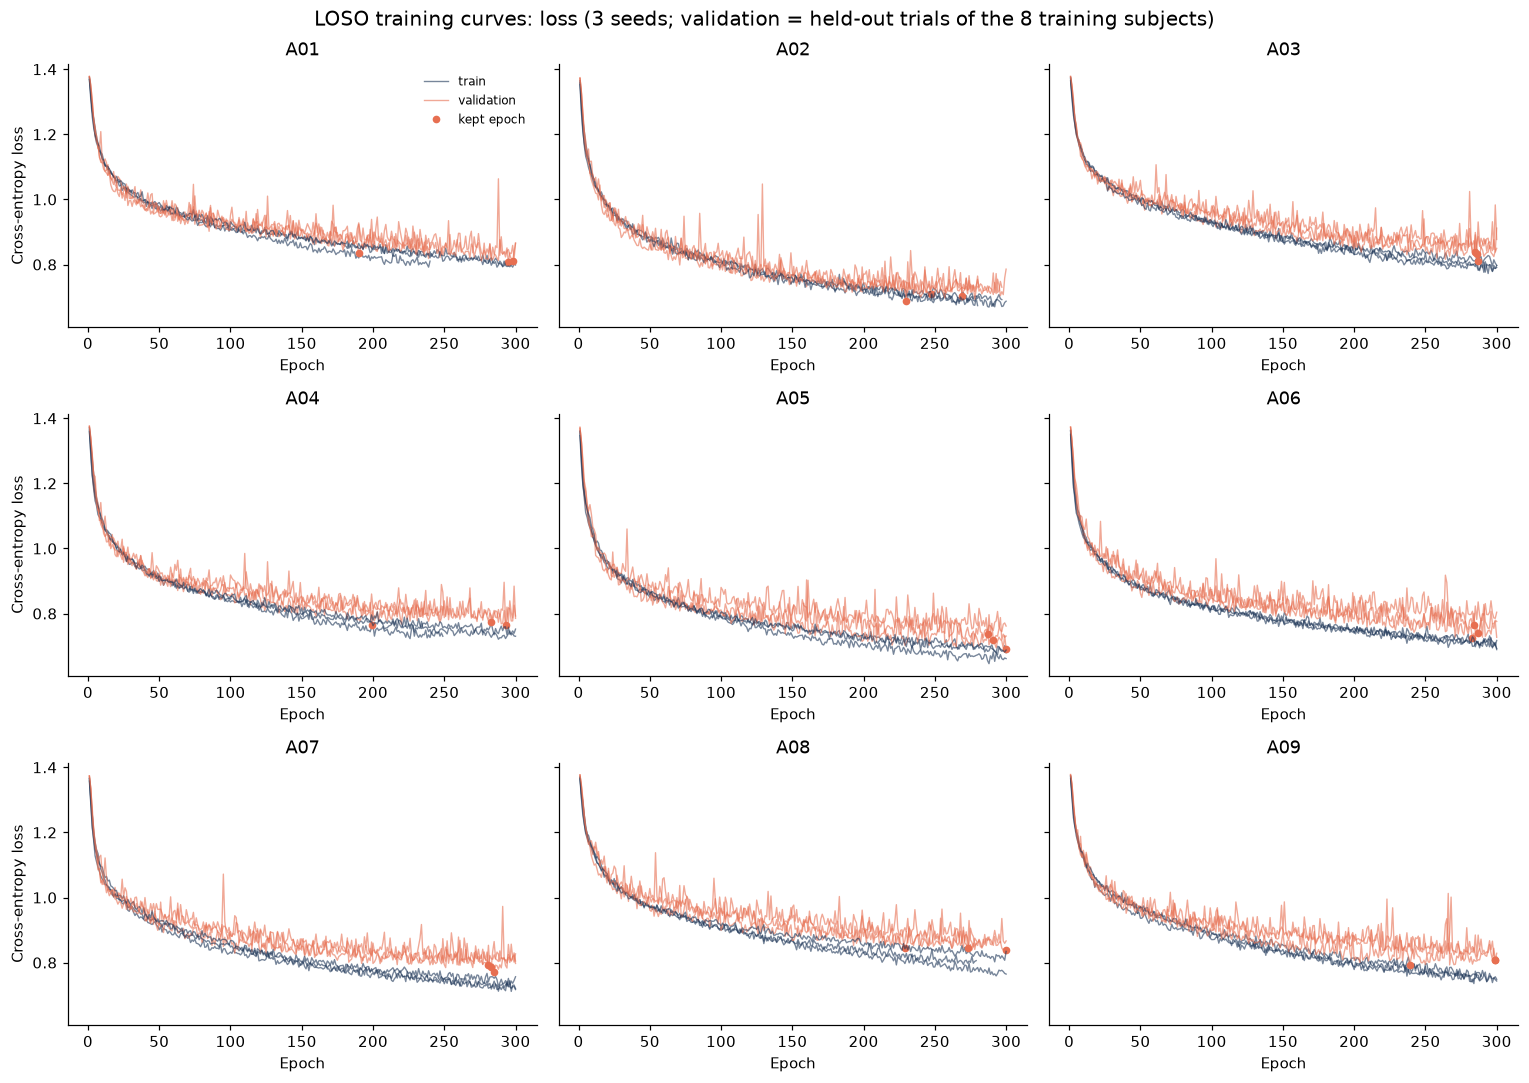

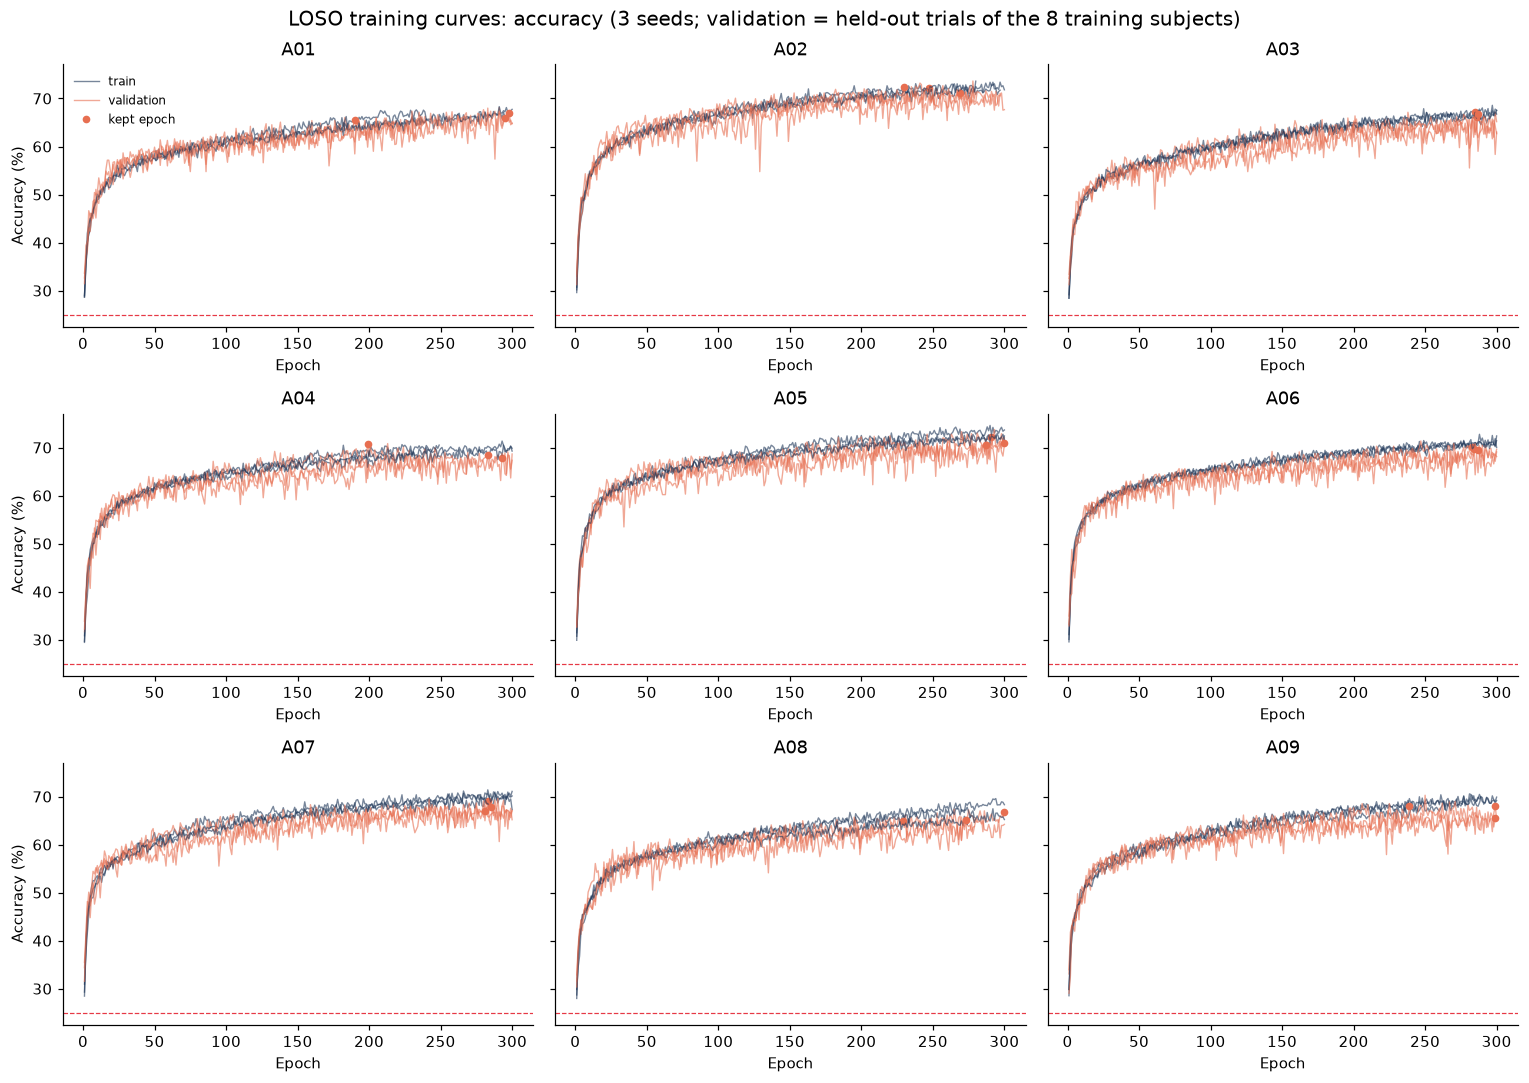

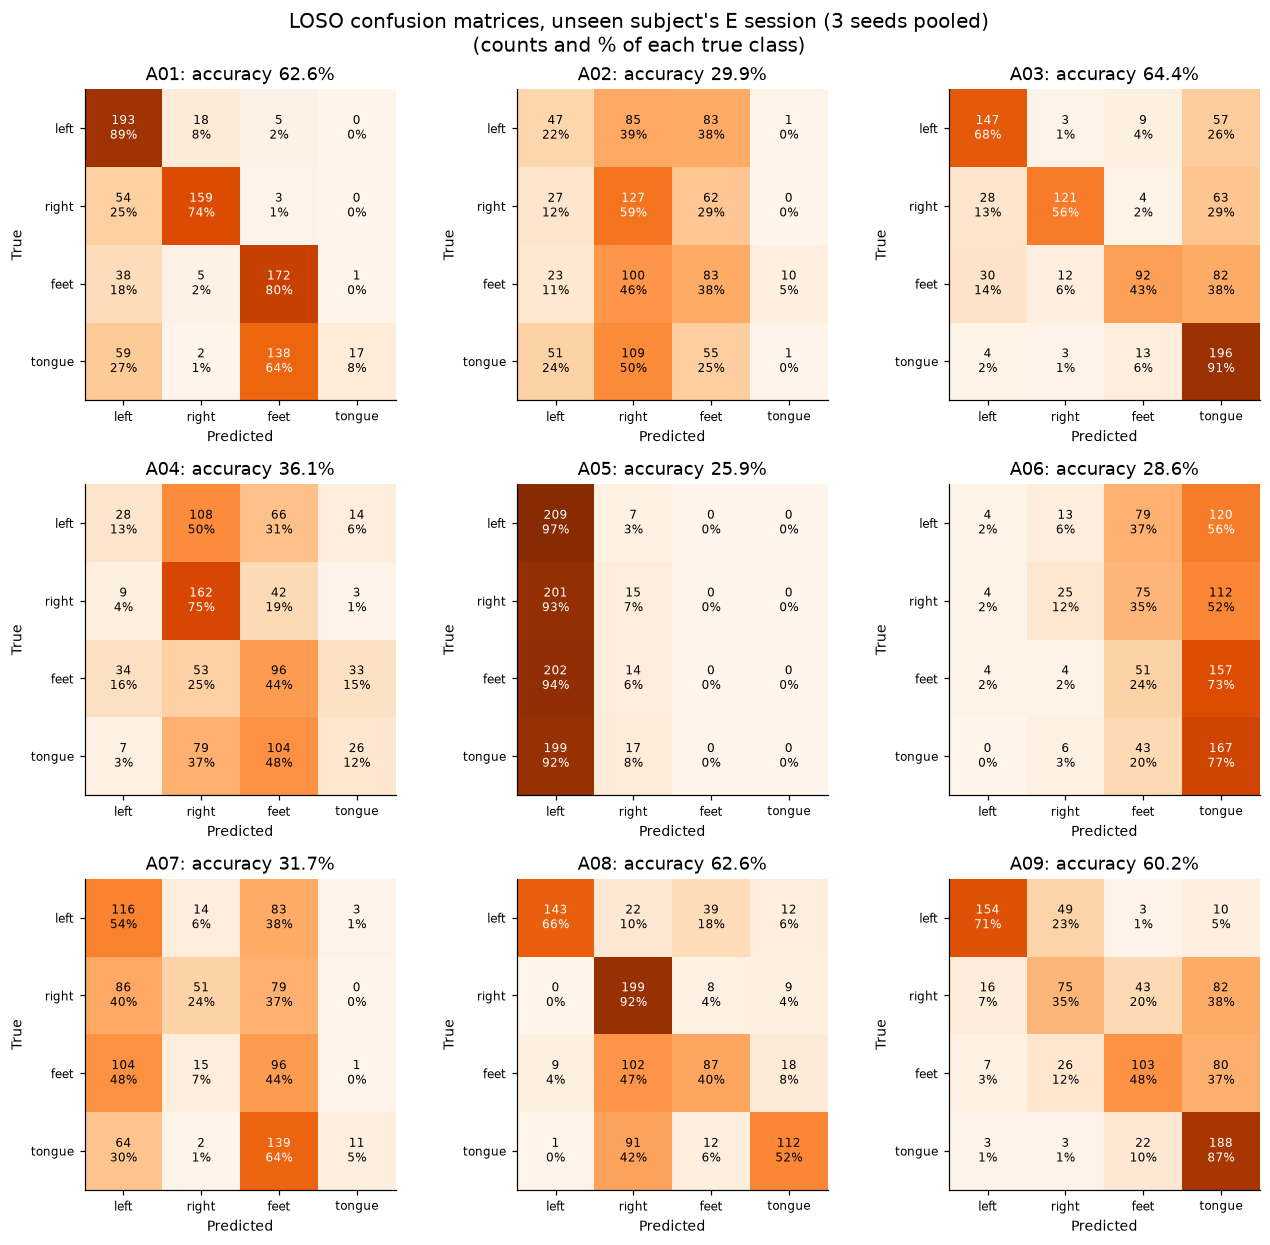

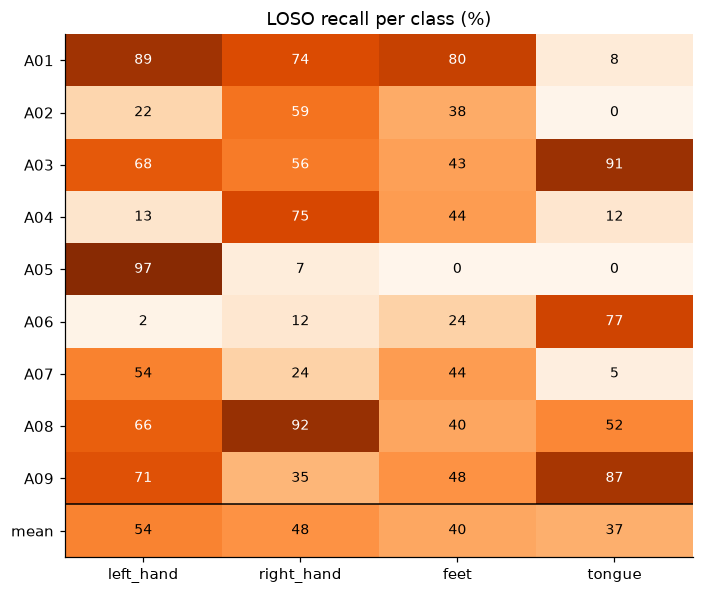

,left_hand,right_hand,feet,tongue
A01,89.4,73.6,79.6,7.9
A02,21.8,58.8,38.4,0.5
A03,68.1,56.0,42.6,90.7
A04,13.0,75.0,44.4,12.0
A05,96.8,6.9,0.0,0.0
A06,1.9,11.6,23.6,77.3
A07,53.7,23.6,44.4,5.1
A08,66.2,92.1,40.3,51.9
A09,71.3,34.7,47.7,87.0
mean,53.5,48.0,40.1,36.9


In [13]:
ax = tab.iloc[:-1, :2].plot.bar(figsize=(10, 4), color=["#1d3557", "#f4a261"], rot=0, width=0.75)
ax.errorbar(np.arange(9) + 0.19, tab.iloc[:-1, 1].values, yerr=tab.iloc[:-1, 2].values, fmt="none", ecolor="black", capsize=3, lw=1)
ax.axhline(25, color="#e63946", ls="--", lw=1.2, label="chance (25%)")
ax.set_ylim(0, 100); ax.set_ylabel("E-session accuracy (%)")
ax.set_title("Own-data model (T→E) vs model that never saw the person (LOSO, no EA)")
ax.legend(frameon=False, ncol=3, fontsize=8)
ax.figure.savefig(FIG_DIR / "04_within_vs_loso.png", bbox_inches="tight")
plt.show()

lh = {s: [r["history"] for r in loso if r["subject"] == s] for s in SUBJECTS}
plot_curves_grid(lh, "loss", "LOSO training curves: loss (3 seeds; validation = held-out trials of the 8 training subjects)",
                 FIG_DIR / "04_loso_curves_loss.png")
plt.show()
plot_curves_grid(lh, "acc", "LOSO training curves: accuracy (3 seeds; validation = held-out trials of the 8 training subjects)",
                 FIG_DIR / "04_loso_curves_accuracy.png")
plt.show()

lp = pooled_predictions(loso, session="E")
plot_confusion_grid({s: v[0] for s, v in lp.items()}, {s: v[1] for s, v in lp.items()}, CLASS_NAMES,
                    "LOSO confusion matrices, unseen subject's E session (3 seeds pooled)", "Oranges",
                    FIG_DIR / "04_loso_confusion_all_subjects.png")
plt.show()
loso_recall = per_class_recall({s: v[0] for s, v in lp.items()}, {s: v[1] for s, v in lp.items()}, CLASS_NAMES)
plot_recall_heatmap(loso_recall, "LOSO recall per class (%)", "Oranges", FIG_DIR / "04_loso_recall_per_class.png")
plt.show()
loso_recall

## Checkpoints
Every trained model is saved as `checkpoints/<phase>/<option>/<run>.pt`. Each checkpoint contains the model weights, the run's settings, and the per-channel scaler fitted on that run's training data, so a model can be reused on new EEG without retraining.

As a check, checkpoints are reloaded **on their own** (no access to the original training data) and the E-session predictions are recomputed. The **predicted classes must be identical** to the saved results. The raw logits can differ slightly, up to about 1e-2, for two reasons: the GPU computes convolutions in reduced-precision TF32 mode by default, and the training runs used cuDNN benchmark mode, which may pick a different convolution algorithm. Neither changes any prediction.

In [14]:
counts = {p: len(list((CKPT_DIR / p).rglob("*.pt"))) for p in ["select", "t2e", "loso"]}
print("Saved checkpoints:", counts, "| total:", sum(counts.values()))

def reload_and_check(phase, config, name):
    ck = torch.load(CKPT_DIR / phase / config / f"{name}.pt", weights_only=False)
    rec = [r for r in load_runs(phase, config) if f"{r['subject']}_seed{r['seed']}" == name][0]
    model = EEGNet(n_times=ck["settings"]["n_times"], dropout=ck["settings"]["dropout"])
    model.load_state_dict(ck["state_dict"])
    X_e, _ = load_config_data(config, rec["subject"], "E")
    X_e = ((X_e - ck["scaler_mean"]) / ck["scaler_std"]).astype(np.float32)
    logits = predict_logits(model.to("cuda" if torch.cuda.is_available() else "cpu"), X_e)
    saved = np.array(rec["logits"] if phase == "t2e" else rec["target"]["E"]["logits"])
    print(f"{phase}/{config}/{name}: max |logit difference| = {np.abs(logits - saved).max():.1e}, "
          f"identical predictions: {bool((logits.argmax(1) == saved.argmax(1)).all())}")

for s in ["A01", "A05", "A09"]:
    reload_and_check("t2e", CH, f"{s}_seed0")
    reload_and_check("loso", CH, f"{s}_seed0")

Saved checkpoints: {'select': 216, 't2e': 180, 'loso': 27} | total: 423


t2e/A/A01_seed0: max |logit difference| = 3.6e-03, identical predictions: True
loso/A/A01_seed0: max |logit difference| = 1.8e-03, identical predictions: True


t2e/A/A05_seed0: max |logit difference| = 7.8e-03, identical predictions: True


loso/A/A05_seed0: max |logit difference| = 1.2e-03, identical predictions: True


t2e/A/A09_seed0: max |logit difference| = 2.2e-03, identical predictions: True


loso/A/A09_seed0: max |logit difference| = 3.4e-03, identical predictions: True


## Summary

### What was done
| Phase | Result |
|---|---|
| 1. E-session labels | Official labels downloaded and verified for all 18 recordings (T labels match the recorded cues trial by trial) |
| 2. Choice (T only) | Option **A** (8–30 Hz, 0–4 s after cue), **446 epochs**: best cross-validated accuracy in the T session (70.5%; D 69.5%, B 69.4%, C 67.3%) |
| 3. Main result | Train on 288 T trials, test on 288 E trials, 5 seeds |
| 4. All options on E | Same ranking on E: **A is also the best option on the test session** (A 68.2 > B 68.0 > D 66.7 > C 65.8) |
| 5. Cross-subject | LOSO on both sessions, 3 seeds: the no-EA baseline for the project |
| Checkpoints | **423 models saved**; reloaded checkpoints reproduce the saved predictions exactly |

### Main result: standard protocol (T → E), single EEGNet
- **Accuracy 68.20%** (mean over 9 subjects and 5 seeds), **kappa 0.576**, **macro-F1 0.673**.
- Stable across random seeds: the 9-subject mean ranges from 67.3% to 69.4% (std 0.9).
- **+7.4 points over notebook 03** (60.8%), because the model now trains on all 288 trials with a training length chosen by cross-validation.

### Comparison with Nzakuna et al. (2025), same protocol and dataset
| Method | Networks | Accuracy | Kappa |
|---|---|---|---|
| **Ours** | 1 (single deterministic pass) | **68.20%** | **0.576** |
| MCD | 1 (200 stochastic passes averaged) | 71.14% | 0.617 |
| MCSD | 1 (200 stochastic passes averaged) | 70.60% | 0.609 |
| EMCD | 15-model ensemble | 75.35% | 0.671 |
| LEMC-FTDB (proposed) | 15 models × 200 passes | 80.40% | 0.737 |

- **We are 2.9 points below their single-network MCD, and the difference is not statistically significant** (Wilcoxon signed-rank p = 0.25, n = 9).
- On the stronger subjects we **match or beat** it: A01 81.5 vs 81.9, A03 89.7 vs 84.7, A08 78.8 vs 79.5, A09 82.3 vs 73.6.
- The gap comes from weak subjects: A02 (−12.4), A05 (−14.4) and A06 (−7.7). Their own preprocessing (our option D) helps exactly these subjects (A05 54 → 67%, A06 50 → 55%) but hurts the strong ones, so no single preprocessing is best for everyone. This is another face of between-subject variability.
- Remaining differences to MCD: 200 averaged stochastic passes (a mini-ensemble) and FT-DropBlock regularisation. Uncertainty methods such as MC Dropout are planned later in the project anyway.

### Cross-subject (LOSO, no alignment): the problem this project addresses
- Unseen subject, E session: **44.66%** (kappa 0.26), **23.5 points below** the within-subject 68.20%.
- A02, A05, A06 and A07 are **close to chance (26–32%)** when the model has never seen them.
- Several unseen subjects **collapse onto one or two classes**. For A05, left-hand recall is 97% while feet and tongue are 0%, so nearly every trial becomes LEFT; A06 is pushed towards *tongue*. In a wheelchair, this is a stream of confident wrong commands, which motivates both **Euclidean Alignment** (cross-subject generalisation) and **uncertainty-based rejection** (reliability).

### Limitations
- **LOSO models were still improving at the 300-epoch limit** (validation loss still falling, 19 of 27 models kept an epoch between 280 and 300), so 44.66% is a slight underestimate. The upcoming EA vs no-EA comparison should use a longer budget (identical for both).
- cuDNN benchmark mode (1.8× faster) makes runs reproducible only up to small floating-point differences. Seeds still fix initialisation and batch order.
- The Phase 2 cross-validation numbers are slightly optimistic because the epoch count was chosen on the same curves. This does not affect the E results, which were never used for any choice.
- Our comparison is with one published paper. Their setup differs in regularisation, kernel size and inference.

### Next steps
1. **Euclidean Alignment**: EA vs no-EA under this LOSO protocol, with a longer training budget.
2. **Temperature scaling → predictive entropy → reject option** on the saved logits (`results/runs/*/…json` keep all logits): risk, coverage and false actionable commands.
3. Optional: average several seeds' predictions or use MC Dropout (closer to MCD/EMCD).